# Geospatial Analysis - Landcover Change in Tucson

## Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm, ListedColormap
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject, Resampling
from shapely.geometry import mapping
from sklearn.cluster import KMeans
import seaborn as sns
from rasterio import features
from matplotlib.patches import Patch
import warnings

warnings.filterwarnings('ignore')

## Configuration

In [2]:
DATA_DIR = 'Data'

# file paths for all data layers

nlcd_dir          = os.path.join(DATA_DIR, 'NLCD')
dem_file          = os.path.join(DATA_DIR, 'tucson_dem_mosaic.tif')
watersheds_file   = os.path.join(DATA_DIR, 'Balanced_and_Critical_Watersheds', 'Balanced_and_Critical_Watersheds.shp')
zipcodes_file     = os.path.join(DATA_DIR, 'Zip_Codes',                        'Zip_Codes_(ZIP).shp')
jurisdiction_file = os.path.join(DATA_DIR, 'Jurisdictional_Boundaries',        'Jurisdictional_Boundaries_(JURISBND).shp')

print('DATA_DIR:         ', DATA_DIR)
print('NLCD directory:   ', nlcd_dir)
print('DEM file:         ', dem_file)
print('Watersheds:       ', watersheds_file)
print('Zip Codes:        ', zipcodes_file)
print('Jurisdiction:     ', jurisdiction_file)

DATA_DIR:          Data
NLCD directory:    Data\NLCD
DEM file:          Data\tucson_dem_mosaic.tif
Watersheds:        Data\Balanced_and_Critical_Watersheds\Balanced_and_Critical_Watersheds.shp
Zip Codes:         Data\Zip_Codes\Zip_Codes_(ZIP).shp
Jurisdiction:      Data\Jurisdictional_Boundaries\Jurisdictional_Boundaries_(JURISBND).shp


## Functions

In [3]:
start_year = int(input("Enter the start year: "))
end_year   = int(input("Enter the end year: "))

def read_landcover_rasters(start_year, end_year):
    """
    Reads the NLCD land cover raster for a range of years and returns
    a dictionary of file paths, along with the CRS, transform, and nodata value from the first file found.
    """
    lc_all_years = {}
    lc_files = {} # New dictionary for paths
    lc_crs = None
    lc_transform = None
    lc_nodata = None

    for yr in range(start_year, end_year + 1):
        filepath = os.path.join(
            nlcd_dir,
            f'Annual_NLCD_LndCov_{yr}_CU_C1V1_e88ec285-1ee1-44ad-9f9c-7bef52ff0f40.tiff'
        )
        
        with rasterio.open(filepath) as src:
            lc_all_years[yr] = src.read(1)
            lc_files[yr] = filepath # Store the path
            
            # capture metadata from the first file found
            if lc_crs is None:
                lc_crs = src.crs
                lc_transform = src.transform
                lc_nodata = src.nodata
                
        print(f'  Loaded {yr}  shape: {lc_all_years[yr].shape}')
        
    return lc_all_years, lc_files, lc_crs, lc_transform, lc_nodata


## Analysis

In [4]:
### read all landcover rasters for a range of years

lc_all_years, lc_files, lc_crs, lc_transform, lc_nodata = read_landcover_rasters(start_year, end_year)

print(f'\nTransform: {lc_transform}')
print(f'\nNodata value: {lc_nodata}')
print(f'\nTotal years loaded: {len(lc_all_years)}')
print(f'\nCRS: {lc_crs}')

  Loaded 1985  shape: (3891, 3872)
  Loaded 1986  shape: (3891, 3872)
  Loaded 1987  shape: (3891, 3872)
  Loaded 1988  shape: (3891, 3872)
  Loaded 1989  shape: (3891, 3872)
  Loaded 1990  shape: (3891, 3872)
  Loaded 1991  shape: (3891, 3872)
  Loaded 1992  shape: (3891, 3872)
  Loaded 1993  shape: (3891, 3872)
  Loaded 1994  shape: (3891, 3872)
  Loaded 1995  shape: (3891, 3872)
  Loaded 1996  shape: (3891, 3872)
  Loaded 1997  shape: (3891, 3872)
  Loaded 1998  shape: (3891, 3872)
  Loaded 1999  shape: (3891, 3872)
  Loaded 2000  shape: (3891, 3872)
  Loaded 2001  shape: (3891, 3872)
  Loaded 2002  shape: (3891, 3872)
  Loaded 2003  shape: (3891, 3872)
  Loaded 2004  shape: (3891, 3872)
  Loaded 2005  shape: (3891, 3872)
  Loaded 2006  shape: (3891, 3872)
  Loaded 2007  shape: (3891, 3872)
  Loaded 2008  shape: (3891, 3872)
  Loaded 2009  shape: (3891, 3872)
  Loaded 2010  shape: (3891, 3872)
  Loaded 2011  shape: (3891, 3872)
  Loaded 2012  shape: (3891, 3872)
  Loaded 2013  shape

In [5]:
### read DEM raster and extract metadata

with rasterio.open(dem_file) as src:
    dem_data      = src.read(1).astype(float)
    dem_nodata    = src.nodata
    dem_crs       = src.crs
    dem_transform = src.transform
    dem_bounds    = src.bounds
    dem_res_deg   = abs(src.transform.a)   # pixel width in degrees

# replace nodata values with NaN so they are ignored in calculations
if dem_nodata is not None:
    dem_data[dem_data == dem_nodata] = np.nan

print('DEM file loaded:', dem_file)
print('Array shape:', dem_data.shape)
print('CRS:', dem_crs)
print('Pixel resolution:', dem_res_deg, 'degrees')
print('Elevation range: %.0f m - %.0f m' % (np.nanmin(dem_data), np.nanmax(dem_data)))

DEM file loaded: Data\tucson_dem_mosaic.tif
Array shape: (3613, 7212)
CRS: EPSG:4269
Pixel resolution: 0.000277777777786999 degrees
Elevation range: 161 m - 2793 m


In [6]:
### read shapefiles

# read into GeoDataFrames

watersheds = gpd.read_file(watersheds_file, engine='pyogrio')
zipcodes   = gpd.read_file(zipcodes_file,   engine='pyogrio')
jurisdiction = gpd.read_file(jurisdiction_file, engine='pyogrio')

# read first few rows to check that they loaded correctly

print('--- Watersheds ---')
print(watersheds.head(3), '\n')

print('--- Zip Codes ---')
print(zipcodes.head(3), '\n')

print('--- Jurisdictional Boundaries ---')
print(jurisdiction.head(3))

--- Watersheds ---
   ID              WATERSHED    STATUS   URL DATASOURCE  \
0   0           Kreuger Wash  critical  None    BALCRIT   
1   0         Ruthrauff Wash  critical  None    BALCRIT   
2   0  Christopher City Wash  balanced  None    BALCRIT   

                                 GlobalID  OBJECTID  vectorsdeG    ShapeSTAre  \
0  {6379DB96-A6C0-47DB-9620-3EF2F8BA40AE}         1    10630918  1.113190e+07   
1  {511770AF-22C2-4D18-BB5E-819332843A44}         2    79348918  7.907498e+07   
2  {010372FB-DEDE-4D77-9577-43DCFCAC4B79}         3     6260600  6.328645e+06   

     ShapeSTLen                                           geometry  
0  20927.487021  POLYGON ((983073.272 458640.441, 983051.226 45...  
1  69755.711218  POLYGON ((983435.12 468153.116, 983482.163 468...  
2  13544.336517  POLYGON ((1014268.968 461917.704, 1014452.006 ...   

--- Zip Codes ---
   OBJECTID ZIPCODE    ZIPCITY   ALTCITY      ZIPTYPE DATASOURCE PC_UID  \
0         1   85321        AJO       WHY     STA

In [7]:
### manage shapefile projections

# print the CRS of every shapefile for comparison

print('DEM CRS:         ', dem_crs)
print('Watersheds CRS:  ', watersheds.crs)
print('Zip Codes CRS:   ', zipcodes.crs)
print('Jurisdiction CRS:', jurisdiction.crs)

# check whether each shapefile matches the DEM CRS

print('\nDo shapefile projections match the DEM raster?')
print('  Watersheds:   ', watersheds.crs == dem_crs)
print('  Zip Codes:    ', zipcodes.crs == dem_crs)
print('  Jurisdiction: ', jurisdiction.crs == dem_crs)

# if the shapefile layers don't match the DEM CRS, reproject them to the DEM CRS

watersheds   = watersheds.to_crs(dem_crs)
zipcodes     = zipcodes.to_crs(dem_crs)
jurisdiction = jurisdiction.to_crs(dem_crs)

# verify reprojection worked

print('\nAfter reprojection:')
print('  Watersheds match DEM raster:   ', watersheds.crs == dem_crs)
print('  Zip Codes match DEM raster:    ', zipcodes.crs == dem_crs)
print('  Jurisdiction match DEM raster: ', jurisdiction.crs == dem_crs)

DEM CRS:          EPSG:4269
Watersheds CRS:   EPSG:2868
Zip Codes CRS:    EPSG:3857
Jurisdiction CRS: EPSG:3857

Do shapefile projections match the DEM raster?
  Watersheds:    False
  Zip Codes:     False
  Jurisdiction:  False

After reprojection:
  Watersheds match DEM raster:    True
  Zip Codes match DEM raster:     True
  Jurisdiction match DEM raster:  True


In [8]:
### manage raster projections

# print the CRS of every raster for comparison

print('DEM CRS:         ', dem_crs)
print('Landcover CRS:  ', lc_crs)

# check whether each raster matches the DEM CRS

print('\nDo raster projections match the DEM raster?')
print('  Landcover:    ', lc_crs == dem_crs)

# initialize an empty dictionary to hold reprojected landcover rasters for each year

lc_reproj_all_years = {}

# write the first year's values to facilitate checking shape below

first_year = list(lc_all_years.keys())[0]

# prepare to reproject landcover raster to match DEM

print('Before reprojection:')
print('  DEM shape:      ', dem_data.shape)
print('  DEM CRS:        ', dem_crs)
print('  Landcover shape:', lc_all_years[first_year].shape)
print('  Landcover CRS:  ', lc_crs)

# loop through each year of landcover data, reproject it to match the DEM, and store in the dictionary

for year, lc_data in lc_all_years.items():
    # initialize an empty array to hold the reprojected landcover data for this year
    lc_reproj = np.empty(dem_data.shape, dtype=np.float32) 

    # open the specific file for this year using the new dictionary
    with rasterio.open(lc_files[year]) as src:
        reproject(
            source        = rasterio.band(src, 1), 
            destination   = lc_reproj,
            dst_transform = dem_transform,
            dst_crs       = dem_crs,
            resampling    = Resampling.nearest, # use nearest neighbor to preserve landcover class values
        )

    lc_reproj_all_years[year] = lc_reproj
    print(f'  Reprojected landcover for {year}...')

# qc check

print('\nAfter reprojection:')
print('  Reprojected landcover shape (last year):', lc_reproj_all_years[year].shape)
print('  Shapes match (last year):', lc_reproj_all_years[year].shape == dem_data.shape)

DEM CRS:          EPSG:4269
Landcover CRS:   PROJCS["AEA        WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

Do raster projections match the DEM raster?
  Landcover:     False
Before reprojection:
  DEM shape:       (3613, 7212)
  DEM CRS:         EPSG:4269
  Landcover shape: (3891, 3872)
  Landcover CRS:   PROJCS["AEA        WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenw

In [9]:
### decide on spatial subsetting approach

# inspect the jurisdiction shapefile layer

print('--- Jurisdictional Boundaries ---')
print('CRS:', jurisdiction.crs)
print('Columns:', list(jurisdiction.columns))
print(jurisdiction['NAME'].unique())

# select a jurisdiction polygon from the jurisdiction GeoDataFrame

jurisdiction_col = 'NAME' 
jurisdiction_val = 'TUCSON' 

single_jurisdiction = jurisdiction[jurisdiction[jurisdiction_col] == jurisdiction_val]

# check how many watersheds have status of "critical" within the specified jurisdiction

# spatially join the watersheds to the single jurisdiction polygon to find which watersheds intersect it
ov_watersheds = gpd.sjoin(watersheds, single_jurisdiction, predicate='intersects')
# count how many of the intersecting watersheds have a STATUS of "critical"
num_critical_ov = (ov_watersheds['STATUS'] == 'critical').sum()

print(f"Total watersheds intersecting {jurisdiction_val}: {len(ov_watersheds)}")
print(f"Critical watersheds in {jurisdiction_val}: {num_critical_ov}")

--- Jurisdictional Boundaries ---
CRS: GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4269"]]
Columns: ['OBJECTID', 'NAME', 'INCORP', 'PC_UID', 'DATASOURCE', 'ShapeSTAre', 'ShapeSTLen', 'geometry']
['ORO VALLEY' 'MARANA' 'TUCSON' 'SOUTH TUCSON' 'SAHUARITA'
 'UNINCORPORATED PIMA COUNTY']
Total watersheds intersecting TUCSON: 21
Critical watersheds in TUCSON: 8


Original DEM shape:        (3613, 7212)
Clipped DEM shape (TUCSON): (1163, 1270)


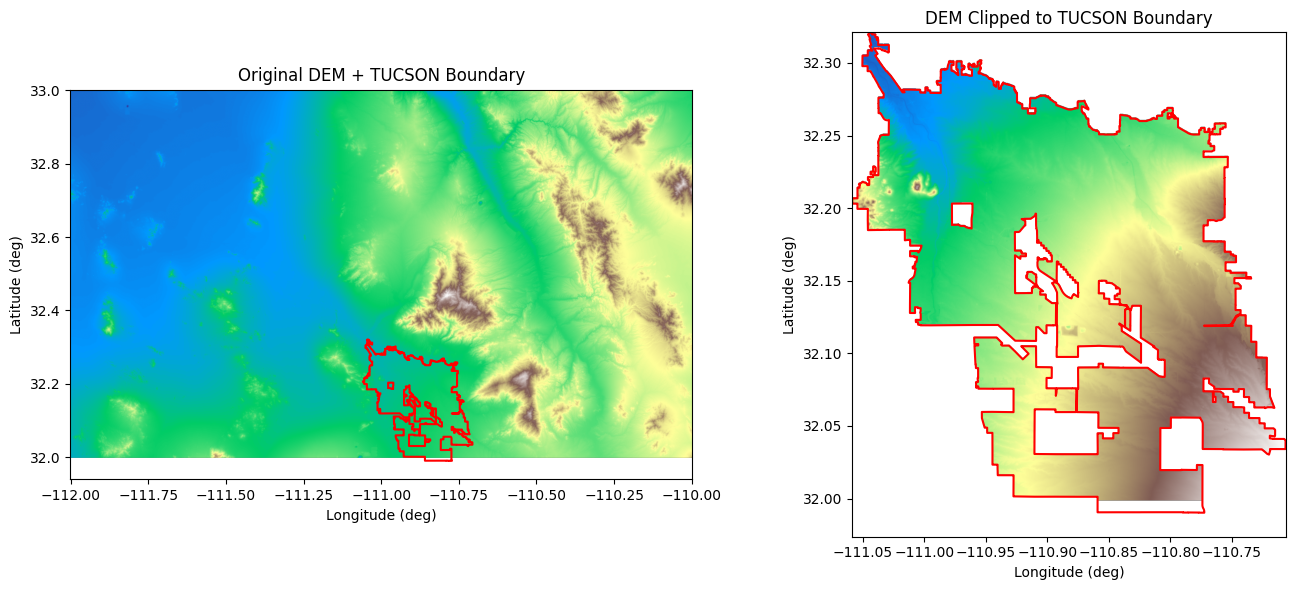

In [10]:
### clip the DEM raster to the extent of the desired jurisdiction shapefile layer

# convert geometry to the format rasterio needs

single_jurisdiction_shape = [mapping(geom) for geom in single_jurisdiction.geometry]

# clip the DEM to the jurisdiction polygon

with rasterio.open(dem_file) as src:
    dem_clipped, clip_transform = rio_mask(src, single_jurisdiction_shape, crop=True)
    dem_bounds = src.bounds

# remove the singleton band dimension

dem_clipped = dem_clipped[0]

# qc check

print('Original DEM shape:       ', dem_data.shape)
print(f'Clipped DEM shape ({jurisdiction_val}):', dem_clipped.shape)

# prepare data for plotting (handle nodata)
# using np.nan for display, assuming dem_nodata is defined or using a common value like -9999

nodata_val = dem_nodata if dem_nodata is not None else -9999

orig_display = dem_data.copy().astype(float)
orig_display[dem_data == nodata_val] = np.nan

clip_display = dem_clipped.copy().astype(float)
clip_display[dem_clipped == nodata_val] = np.nan

# calculate extents

# original extent
extent_orig = [dem_bounds.left, dem_bounds.right, dem_bounds.bottom, dem_bounds.top]

# clipped extent using the new transform
rows_c, cols_c = dem_clipped.shape
left_c   = clip_transform.c
top_c    = clip_transform.f
right_c  = left_c + clip_transform.a * cols_c
bottom_c = top_c + clip_transform.e * rows_c
extent_clip = [left_c, right_c, bottom_c, top_c]

# verify by plotting

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap_elev = 'terrain'

# original DEM with jurisdiction boundary
im0 = axes[0].imshow(orig_display, cmap=cmap_elev, extent=extent_orig, origin='upper')
single_jurisdiction.boundary.plot(ax=axes[0], edgecolor='red', linewidth=1.5)
axes[0].set_title(f'Original DEM + {jurisdiction_val} Boundary')
axes[0].set_xlabel('Longitude (deg)')
axes[0].set_ylabel('Latitude (deg)')

# clipped DEM with jurisdiction boundary
im1 = axes[1].imshow(clip_display, cmap=cmap_elev, extent=extent_clip, origin='upper')
single_jurisdiction.boundary.plot(ax=axes[1], edgecolor='red', linewidth=1.5)
axes[1].set_title(f'DEM Clipped to {jurisdiction_val} Boundary')
axes[1].set_xlabel('Longitude (deg)')
axes[1].set_ylabel('Latitude (deg)')

plt.tight_layout()
plt.show()

Optimal Breaks for 3 Classes: [782.0, 861.0]


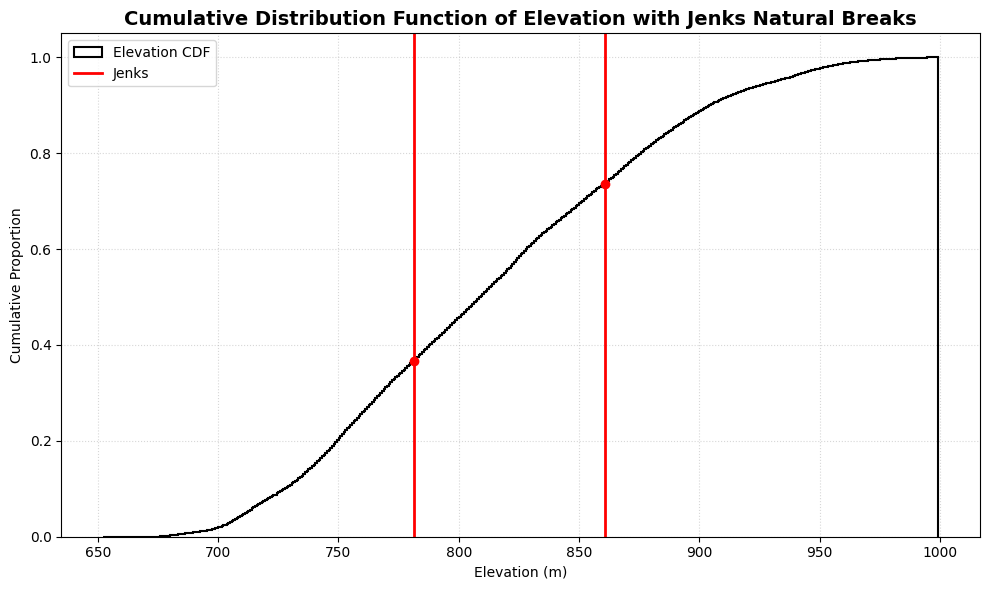

In [11]:
### interrogate the clipped DEM raster - cumulative distribution function (CDF)

# prepare the data by flattening and removing NaNs

dem_clean = dem_clipped.copy().astype(float)
dem_clean[dem_clipped == dem_nodata] = np.nan
valid_elev = dem_clean[~np.isnan(dem_clean)].reshape(-1, 1)

# specify the number of clusters/classes we want to identify using Jenks Natural Breaks

n_clusters = 3

# run KMeans clustering to find natural groupings in the elevation data

# groups the data into the specified number of clusters based on natural variance
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(valid_elev)

# extract the cluster centres (the mean elevation of each cluster)

# sort the centres and find the midpoints between them to use as breaks
centres = sorted(kmeans.cluster_centers_.flatten())
jenks_breaks = [(centres[i] + centres[i+1]) / 2 for i in range(len(centres)-1)]

print(f"Optimal Breaks for {n_clusters} Classes: {[round(b, 0) for b in jenks_breaks]}")

fig, ax = plt.subplots(figsize=(10, 6))

# plot the CDF

ax.hist(valid_elev, bins=500, density=True, cumulative=True, 
        histtype='step', color='black', linewidth=1.5, label='Elevation CDF')

# plot the Jenks breaks on the CDF

for j in jenks_breaks:
    p = np.mean(valid_elev <= j)
    ax.axvline(j, color='red', linestyle='-', linewidth=2, label=f'Jenks' if j==jenks_breaks[0] else "")
    ax.scatter(j, p, color='red', zorder=5) # mark the break points on the CDF

# finalize the plot

ax.set_title('Cumulative Distribution Function of Elevation with Jenks Natural Breaks', fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Proportion')
ax.set_xlabel('Elevation (m)')
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [12]:
### reclassify NLCD classes

# official NLCD class codes, labels, and hex colors
# source: https://www.mrlc.gov/data/type/land-cover

NLCD_CLASSES_OFFICIAL = {
    11: ('Open Water',                '#476BA0'),
    12: ('Perennial Ice/Snow',        '#D1DDF9'),
    21: ('Developed, Open Space',     '#DDC9C9'),
    22: ('Developed, Low Intensity',  '#D89382'),
    23: ('Developed, Med Intensity',  '#ED0000'),
    24: ('Developed, High Intensity', '#AA0000'),
    31: ('Barren Land',               '#B2ADA3'),
    41: ('Deciduous Forest',          '#68AB5F'),
    42: ('Evergreen Forest',          '#1C5F2C'),
    43: ('Mixed Forest',              '#B5C58F'),
    51: ('Dwarf Scrub',               '#AF963C'),
    52: ('Shrub/Scrub',               '#CCB879'),
    71: ('Grassland/Herbaceous',      '#DFDFC2'),
    72: ('Sedge/Herbaceous',          '#D1D182'),
    73: ('Lichens',                   '#A3CC51'),
    74: ('Moss',                      '#82BA9E'),
    81: ('Pasture/Hay',               '#DCD939'),
    82: ('Cultivated Crops',          '#AB6C28'),
    90: ('Woody Wetlands',            '#B8D9EB'),
    95: ('Emergent Herb. Wetlands',   '#6C9FB8')
}

# group the NLCD classes into broader categories for easier interpretation

NLCD_GROUPS = {
    'Water/Ice': [11, 12],
    'Developed': [21, 22, 23, 24],
    'Barren':    [31],
    'Naturally Vegetated': [41, 42, 43, 51, 52, 71, 72, 73, 74],
    'Agricultural':  [81, 82],
    'Wetlands':  [90, 95]
}

# create a flat dictionary for fast lookup: {11: 'Water/Ice', 21: 'Developed', ...}
CODE_TO_GROUP = {code: group_name for group_name, codes in NLCD_GROUPS.items() for code in codes}


In [13]:
### map the DEM pixels based on the Jenks Natural Breaks

class_bins = [-np.inf] + jenks_breaks + [np.inf]
elev_class = np.digitize(dem_clipped, class_bins)
elev_class = np.where(dem_clipped == dem_nodata, np.nan, elev_class)

### write a function to assign elevation class labels based on the Jenks Natural Breaks

# initialize a dictionary to hold the elevation class labels for each cluster
elevation_labels = {}

# first cluster
elevation_labels[0] = f"< {jenks_breaks[0]:.0f}m"

# middle clusters
for i in range(len(jenks_breaks) - 1):
    elevation_labels[i+1] = f"{jenks_breaks[i]:.0f} - {jenks_breaks[i+1]:.0f}m"

# last cluster
elevation_labels[len(centres)-1] = f"> {jenks_breaks[-1]:.0f}m"

In [14]:
### count pixels per NLCD group within each elevation band defined by the Jenks Natural Breaks
### convert pixel counts to area in km² for each NLCD group within each elevation band

# cosine adjustment for longitude distance at selected jurisdiction latitude

COS_ADJ = 32.2

# calculate the corrected pixel area (km²)

res_lat_m = dem_res_deg * 111000
res_lon_m = dem_res_deg * (111000 * np.cos(np.radians(COS_ADJ))) # cosine adjustment for latitude
pixel_area_km2 = (res_lat_m * res_lon_m) / 1_000_000

# calculate the offsets between the full DEM and the clipped DEM
off_x = int(round((clip_transform.c - dem_transform.c) / dem_transform.a))
off_y = int(round((clip_transform.f - dem_transform.f) / dem_transform.e))

# get the shape of the clipped DEM
h_dem_clipped, w_dem_clipped = dem_clipped.shape

# loop through each year and elevation band, count pixels in each NLCD group, and calculate area

for year, lc_full in lc_reproj_all_years.items():
    print(f'\n{"="*30} YEAR: {year} {"="*30}')
    
    # slice the full landcover to match the clipped DEM window
    # [rows, columns] -> [start_row : start_row + height, start_col : start_col + width]
    lc_data = lc_full[off_y : off_y + h_dem_clipped, off_x : off_x + w_dem_clipped]

    for band_id, band_label in elevation_labels.items():
        band_mask = (elev_class == band_id)
        
        if not np.any(band_mask):
            continue

        lc_in_band = lc_data[band_mask].astype(int)

        # use the data from the reprojected dictionary directly
        lc_in_band = lc_data[band_mask].astype(int)
        class_codes, class_counts = np.unique(lc_in_band, return_counts=True)

        category_data = []
        for code, count in zip(class_codes, class_counts):
            if int(code) == int(lc_nodata): 
                continue
            
            group_name = CODE_TO_GROUP.get(int(code), "Other/Unknown")
            area_km2 = count * pixel_area_km2
            
            category_data.append({
                'Group': group_name,
                'Pixels': count,
                'Area_km2': area_km2
            })

        if category_data:
            df = pd.DataFrame(category_data)
            df_grouped = df.groupby('Group').sum().reset_index()
            df_grouped = df_grouped.sort_values('Area_km2', ascending=False)

            print(f'\n--- Elevation band: {band_label} ---')
            print(df_grouped.to_string(index=False, formatters={'Area_km2': '{:,.2f}'.format}))


============================== YEAR: 1985 ==============================

--- Elevation band: 782 - 861m ---
              Group  Pixels Area_km2
          Developed  222741   179.19
Naturally Vegetated   58500    47.06
       Agricultural     457     0.37
          Water/Ice     363     0.29
           Wetlands     287     0.23

--- Elevation band: > 861m ---
              Group  Pixels Area_km2
Naturally Vegetated  176611   142.08
          Developed  108377    87.19
           Wetlands      95     0.08
             Barren      87     0.07
          Water/Ice      74     0.06
       Agricultural      29     0.02

============================== YEAR: 1986 ==============================

--- Elevation band: 782 - 861m ---
              Group  Pixels Area_km2
          Developed  223397   179.72
Naturally Vegetated   57867    46.55
       Agricultural     432     0.35
          Water/Ice     365     0.29
           Wetlands     287     0.23

--- Elevation band: > 861m ---
             

In [15]:
### group the watersheds by their "critical" status and focus on the critical ones

critical_watersheds = watersheds[watersheds['STATUS'].str.lower() == 'critical'].copy()

print(f"Processing {len(critical_watersheds)} CRITICAL watersheds...") # qc check

# loop through each year and elevation band
# also mask to each critical watershed
# count pixels as area in each NLCD group within that watershed and elevation band

h, w = elev_class.shape

for year, lc_full in lc_reproj_all_years.items():
        
    # slice the reprojected landcover to match selected jurisdiction extent
    lc_juris = lc_full[off_y : off_y + h, off_x : off_x + w]

    for idx, row in critical_watersheds.iterrows():
        ws_name = row['BASIN_NAME'] if 'BASIN_NAME' in row else row['WATERSHED']
        
        # spatial mask: for this watershed, where are the pixels that belong to it?
        ws_mask = features.rasterize(
            [(row['geometry'], 1)],
            out_shape=(h, w),
            transform=clip_transform,
            fill=0
        ).astype(bool)

        for band_id, band_label in elevation_labels.items():
            # combined mask: in this elevation band AND this watershed
            combined_mask = (elev_class == band_id) & ws_mask
            
            if not np.any(combined_mask):
                continue

            # extract pixels and aggregate
            pixels = lc_juris[combined_mask]
            codes, counts = np.unique(pixels, return_counts=True)

            ws_band_rows = []
            for code, count in zip(codes, counts):
                if int(code) == int(lc_nodata): continue
                group_name = CODE_TO_GROUP.get(int(code), "Other")
                ws_band_rows.append({
                    'Group': group_name, 
                    'Area (km2)': count * pixel_area_km2
                })

            if ws_band_rows:
                df_res = pd.DataFrame(ws_band_rows).groupby('Group').sum().reset_index()
                df_res = df_res.sort_values('Area (km2)', ascending=False)

print(f"\nProcessing complete! Processed {len(lc_reproj_all_years)} years across {len(critical_watersheds)} CRITICIAL watersheds!")


Processing 8 CRITICAL watersheds...

Processing complete! Processed 40 years across 8 CRITICIAL watersheds!


### Pre-Processing

In [16]:
### create a master DataFrame that contains 
# the area of each NLCD group within each elevation band for each critical watershed and year

# initialize a list to hold all results
all_results = []

# loop through each year, then each critical watershed, then each elevation band, and count pixels in each NLCD group
for year, lc_full in lc_reproj_all_years.items():
    lc_tucson = lc_full[off_y : off_y + h, off_x : off_x + w]

    for idx, row in critical_watersheds.iterrows():
        ws_name = row['BASIN_NAME'] if 'BASIN_NAME' in row else row['WATERSHED']
        ws_mask = features.rasterize([(row['geometry'], 1)], out_shape=(h, w), transform=clip_transform, fill=0).astype(bool)

        for band_id, band_label in elevation_labels.items():
            combined_mask = (elev_class == band_id) & ws_mask
            if not np.any(combined_mask): continue

            pixels = lc_tucson[combined_mask]
            codes, counts = np.unique(pixels, return_counts=True)

            for code, count in zip(codes, counts):
                if int(code) == int(lc_nodata): continue
                group_name = CODE_TO_GROUP.get(int(code), "Other")
                
                # append a flat dictionary for each data point
                all_results.append({
                    'Year': year,
                    'Watershed': ws_name,
                    'Band': band_label,
                    'Group': group_name,
                    'Area_km2': count * pixel_area_km2
                })

# convert the list of dicts to the DataFrame the plot is looking for
df_master = pd.DataFrame(all_results)


### Pre-Plotting QC Check

In [17]:
### check the total area across all groups and bands for each year
### ensure it matches the expected watershed area

# group by year and sum the area to check for consistency across years

qc_totals = df_master.groupby('Year')['Area_km2'].sum()

print("QC Check: Total Watershed Area by Year (km²)")
print("-" * 40)
print(qc_totals)
print("-" * 40)

if qc_totals.max() - qc_totals.min() > (qc_totals.mean() * 0.001):
    print("⚠️ WARNING: Total area varies between years! Check your landcover alignment!")
else:
    print("✅ SUCCESS: Total area is consistent across all years!")

# group by year and elevation band to check for consistency in area across bands and years

band_qc = df_master.groupby(['Year', 'Band'])['Area_km2'].sum().unstack(level=1)

print("\nQC Check: Area (km²) per Elevation Band by Year")
print("=" * 60)
print(band_qc.round(2)) # Rounding to 2 decimals for readability
print("=" * 60)

# calculate the standard deviation across years for each band
variation = band_qc.std()

if variation.max() > 0.01:
    print("⚠️ WARNING: Some variation detected in elevation band totals! Check your clipping offsets!")
else:
    print("✅ SUCCESS: Elevation band totals are stable across all years!")



QC Check: Total Watershed Area by Year (km²)
----------------------------------------
Year
1985    43.099541
1986    43.099541
1987    43.099541
1988    43.099541
1989    43.099541
1990    43.099541
1991    43.099541
1992    43.099541
1993    43.099541
1994    43.099541
1995    43.099541
1996    43.099541
1997    43.099541
1998    43.099541
1999    43.099541
2000    43.099541
2001    43.099541
2002    43.099541
2003    43.099541
2004    43.099541
2005    43.099541
2006    43.099541
2007    43.099541
2008    43.099541
2009    43.099541
2010    43.099541
2011    43.099541
2012    43.099541
2013    43.099541
2014    43.099541
2015    43.099541
2016    43.099541
2017    43.099541
2018    43.099541
2019    43.099541
2020    43.099541
2021    43.099541
2022    43.099541
2023    43.099541
2024    43.099541
Name: Area_km2, dtype: float64
----------------------------------------
✅ SUCCESS: Total area is consistent across all years!

QC Check: Area (km²) per Elevation Band by Year
Band  782 - 86

### Plotting

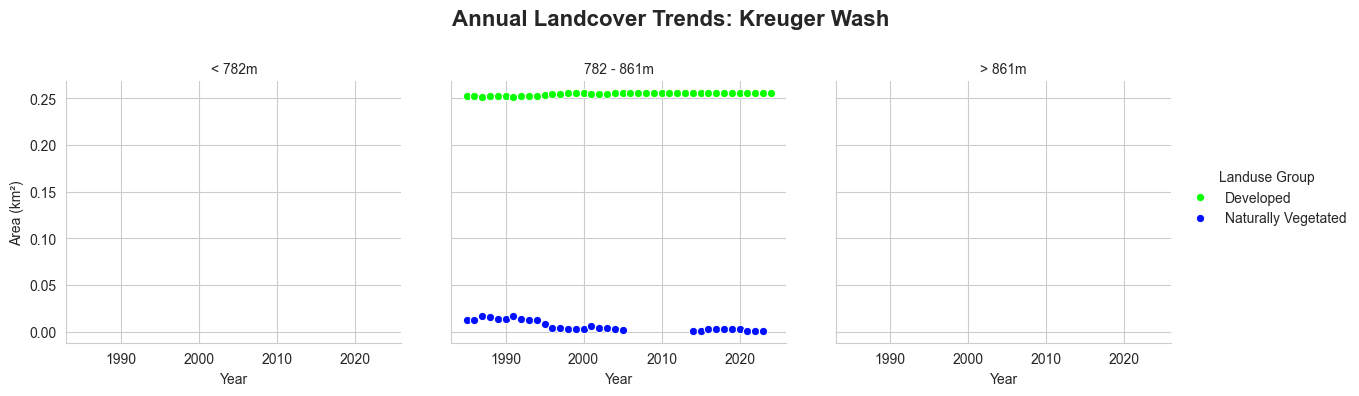

Total Watershed Area: ~1.02 km²


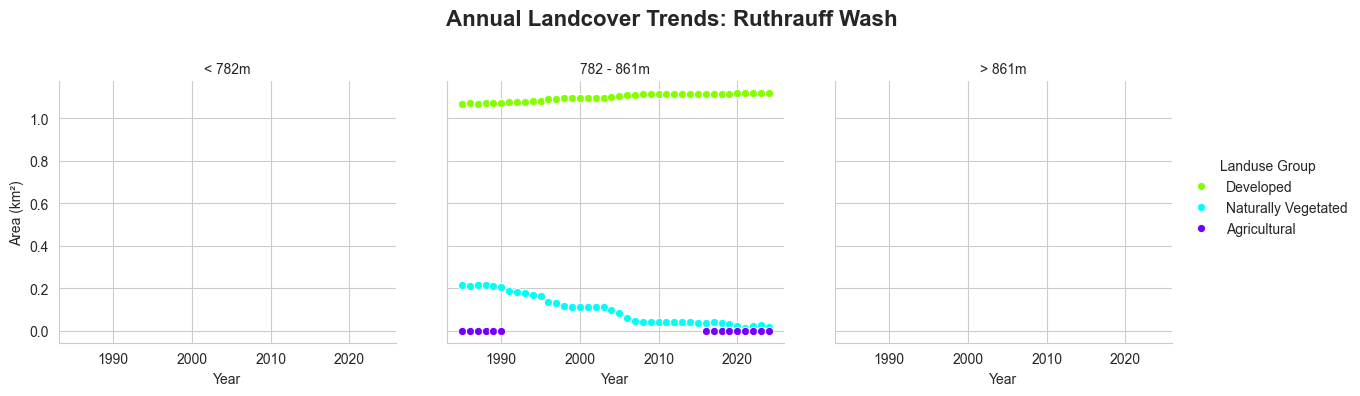

Total Watershed Area: ~4.49 km²


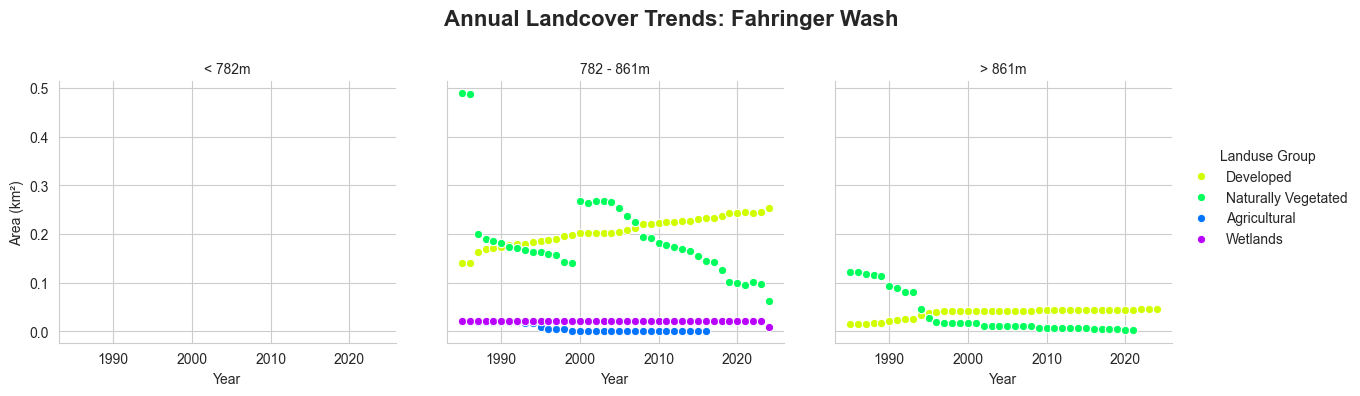

Total Watershed Area: ~1.27 km²


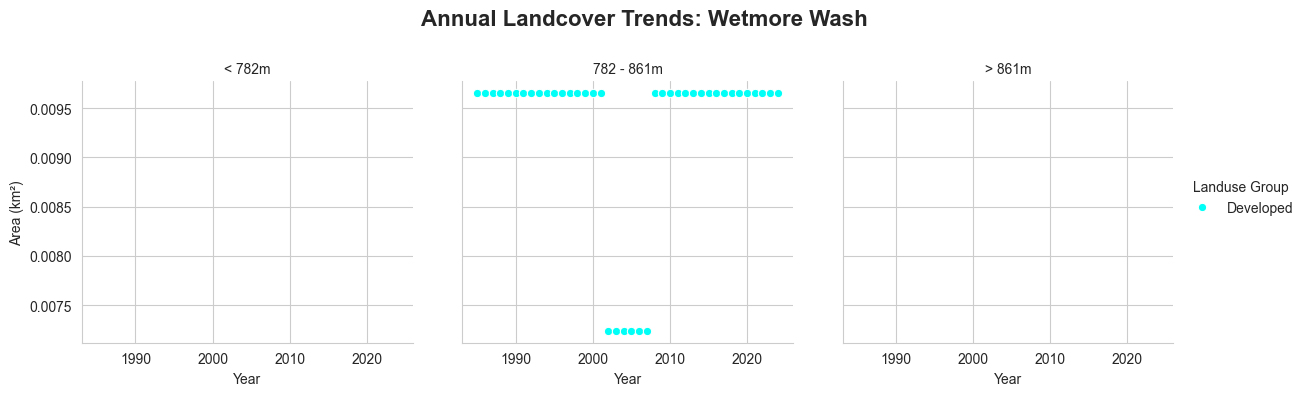

Total Watershed Area: ~0.03 km²


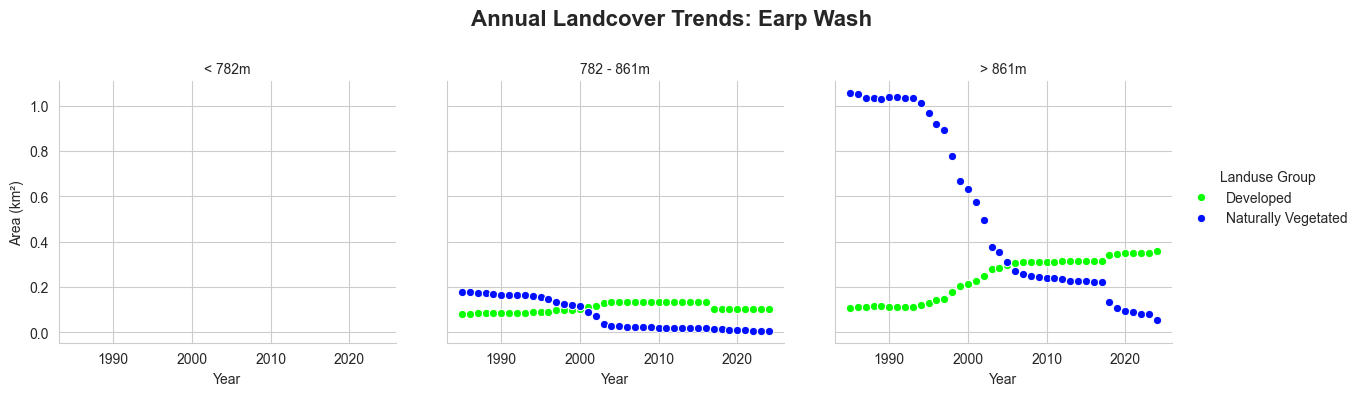

Total Watershed Area: ~1.90 km²


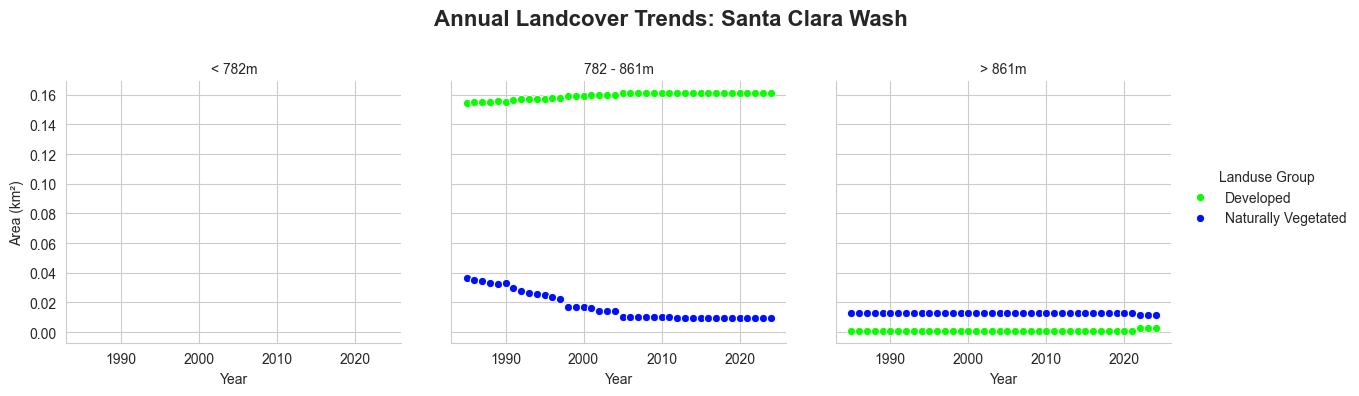

Total Watershed Area: ~0.67 km²


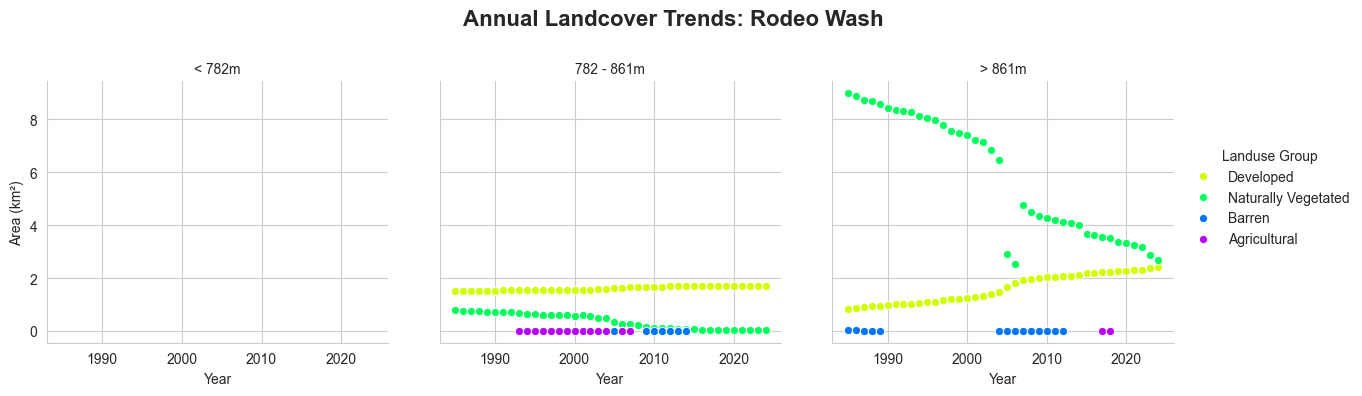

Total Watershed Area: ~19.21 km²


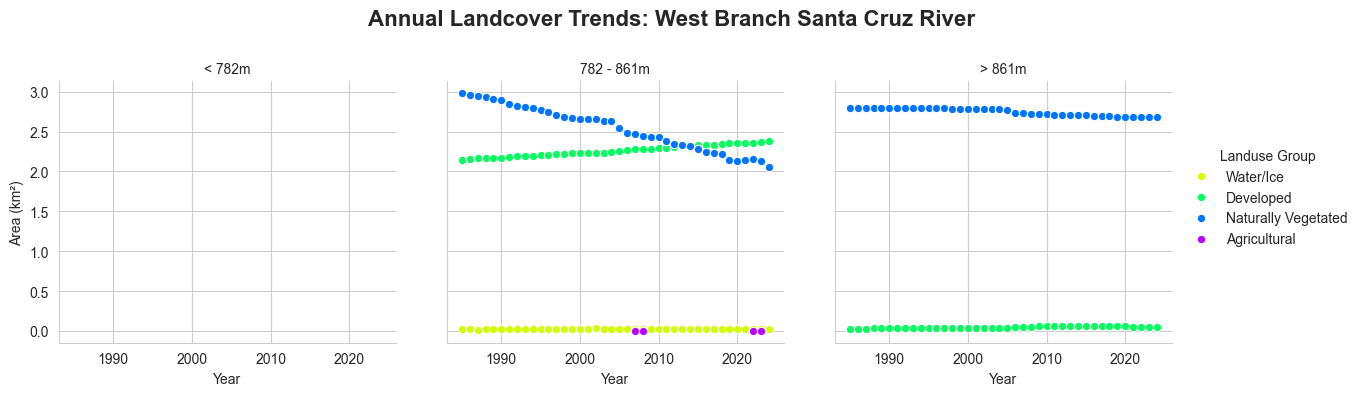

Total Watershed Area: ~14.50 km²


In [18]:
### plot the trends for each watershed, with one line per NLCD group, and one facet per elevation band

# set a consistent order for the elevation bands across all watersheds

fixed_band_order = [elevation_labels[i] for i in sorted(elevation_labels.keys())]

# set seaborn style for clean plots

sns.set_style("whitegrid", {'axes.facecolor': 'white'})

# loop through each watershed and create a FacetGrid plot for its elevation bands

for ws_name in df_master['Watershed'].unique():
    ws_df = df_master[df_master['Watershed'] == ws_name].copy()
    
    # create a FacetGrid with one column per elevation band, consistent Y-axis, and lines colored by NLCD group
    # sharey=True (default) ensures the Y-axis is consistent across one watershed's bands
    g = sns.FacetGrid(ws_df, 
                      col="Band", 
                      col_order=fixed_band_order, 
                      hue="Group", 
                      palette='hsv',
                      height=4, 
                      aspect=1.0, 
                      sharey=True) # Unified Y-axis for direct comparison

    # map the lines (errorbar=None removes any shading/confidence intervals)
    g.map(sns.lineplot, "Year", "Area_km2", marker="o", errorbar=None, linestyle='', linewidth=0)

    # enforce white background and strip hidden shading
    for ax in g.axes.flat:
        ax.set_facecolor('white')
        # Remove any lingering shading collections (like 'fill_between')
        for collection in list(ax.collections):
            collection.remove()

    # add legends, titles, and axis labels
    g.add_legend(title="Landuse Group")
    g.set_axis_labels("Year", "Area (km²)")
    g.set_titles(col_template="{col_name}")
    
    plt.subplots_adjust(top=0.8, wspace=0.15)
    g.fig.suptitle(f'Annual Landcover Trends: {ws_name}', fontsize=16, fontweight='bold')

    plt.show()
    
    # confirm the total area of the basin across bands
    total_area = ws_df.groupby('Year')['Area_km2'].sum().mean()
    print(f"Total Watershed Area: ~{total_area:.2f} km²")


### Pre-Mapping QC Check

In [19]:
### compare first and last year's data

years = sorted(lc_reproj_all_years.keys())
if len(years) > 1:
    are_identical = np.array_equal(lc_reproj_all_years[years[0]], lc_reproj_all_years[years[-1]])
    print(f"Data for {years[0]} and {years[-1]} is identical: {are_identical}")

Data for 1985 and 2024 is identical: False


### Mapping

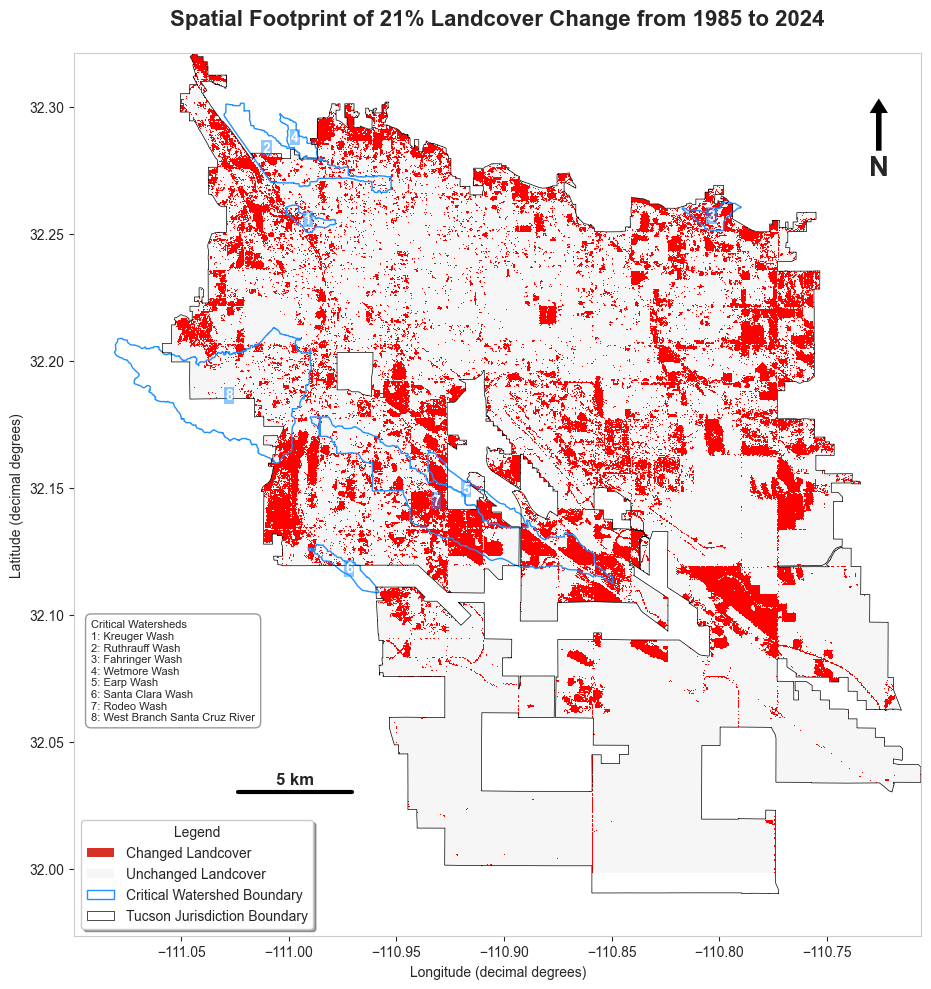

In [20]:
### generate a change map between the first and last year of landcover data

sns.set_style("whitegrid", {'axes.facecolor': 'white'})

# get the first and last year from the loaded landcover data

years = sorted(lc_reproj_all_years.keys())
first_y, last_y = years[0], years[-1]

# mask out areas where the DEM has nodata to avoid plotting changes in those areas

change_map = np.where(lc_reproj_all_years[first_y] != lc_reproj_all_years[last_y], 1, 0)
change_slice = change_map[off_y : off_y + h, off_x : off_x + w].astype(float)
change_slice[np.isnan(dem_clean)] = np.nan

# calculate the percentage of pixels that changed within the jurisdiction, ignoring NaNs

pct_change = (np.nansum(change_slice == 1) / np.nansum(~np.isnan(change_slice))) * 100

# plot

fig, ax = plt.subplots(figsize=(12, 10))

# define a custom colormap

cmap_diff = ListedColormap(["#F6F6F6", "#ff0000"]) 
im = ax.imshow(change_slice, cmap=cmap_diff, extent=extent_clip, origin='upper', interpolation='nearest')

# critical watershed boundaries for context

critical_watersheds.boundary.plot(ax=ax, edgecolor='dodgerblue', linewidth=1, alpha=1)

# jurisdiction boundary for context

single_jurisdiction.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5, alpha=1)

# add a custom legend

legend_elements = [
    Patch(facecolor='#d73027', edgecolor='none', label='Changed Landcover'),
    Patch(facecolor='#F6F6F6', edgecolor='none', label='Unchanged Landcover'),
    Patch(facecolor='none', edgecolor='dodgerblue', label='Critical Watershed Boundary', linewidth=1),
    Patch(facecolor='none', edgecolor='black', label=f'{jurisdiction_val.title()} Jurisdiction Boundary', linewidth=0.5)
]

ax.legend(handles=legend_elements, loc='lower left', title="Legend", frameon=True)

# add titles, labels, and ticks

ax.legend(handles=legend_elements, loc='lower left', title="Legend", 
          frameon=True, shadow=True, facecolor='white')

ax.set_title(f'Spatial Footprint of {int(pct_change)}% Landcover Change from {first_y} to {last_y}', fontsize=16, fontweight='bold')

ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
ax.set_title(f'Spatial Footprint of {int(pct_change)}% Landcover Change from {first_y} to {last_y}', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude (decimal degrees)')
ax.set_ylabel('Latitude (decimal degrees)')

# add north arrow

x_arrow, y_arrow, arrow_len = 0.95, 0.95, 0.08
ax.annotate('N', xy=(x_arrow, y_arrow), xytext=(x_arrow, y_arrow - arrow_len),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=20, fontweight='bold',
            xycoords='axes fraction')

# add scale bar

scale_km = 5
bar_len_deg = scale_km / 94.5 
bar_x = extent_clip[0] + (extent_clip[1] - extent_clip[0]) * 0.1
bar_y = extent_clip[2] + (extent_clip[3] - extent_clip[2]) * 0.1
ax.plot([bar_x, bar_x + bar_len_deg], [bar_y, bar_y], color='black', lw=3)
ax.text(bar_x + (bar_len_deg/2), bar_y + 0.003, f'{scale_km} km', 
        ha='center', fontweight='bold', fontsize=12, zorder=11)

# add labels and a key for the critical watersheds

# assign an unique ID to each critical watershed
critical_watersheds = critical_watersheds.reset_index(drop=True)
critical_watersheds['Map_ID'] = critical_watersheds.index + 1

# add number labels to the critical watersheds on the map
# using the representative point of each watershed for best placement
for idx, row in critical_watersheds.iterrows():
    # Use the representative_point() instead of centroid for complex shapes 
    # to ensure the point is always inside the boundary
    point = row['geometry'].representative_point()
    ax.text(point.x, point.y, str(row['Map_ID']), 
            fontsize=10, fontweight='bold', ha='center', va='center',
            color='white', bbox=dict(facecolor='dodgerblue', alpha=0.5, edgecolor='none', pad=1))

# create a text list of the critical watersheds with their assigned numbers for the key/legend
watershed_list_text = "\n".join([
    f"{row['Map_ID']}: {row['BASIN_NAME'] if 'BASIN_NAME' in row else row['WATERSHED']}"
    for _, row in critical_watersheds.iterrows()
])

# create a formatted key text with a title and the list of watersheds
ws_key_title = "Critical Watersheds\n"
ws_key_items = "\n".join([
    f"{row['Map_ID']}: {row['BASIN_NAME'] if 'BASIN_NAME' in row else row['WATERSHED']}"
    for _, row in critical_watersheds.iterrows()
])
full_key_text = ws_key_title + ws_key_items

# add the key text to the plot
ax.text(0.02, 0.3, full_key_text, 
        transform=ax.transAxes, 
        fontsize=8, 
        verticalalignment='center',
        horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

# polish 

plt.grid(False)
plt.tight_layout()
plt.show()